<a href="https://colab.research.google.com/github/manon306/-/blob/main/Regression2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  **Regression**

1- IMPORT Library

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**2 - READ DATA**

In [35]:
df = pd.read_csv('./insurance.csv')

**Show data**

In [36]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520


**Data tail**

In [37]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3.0,no,northwest,10600.5483
1334,18,female,31.92,0.0,no,northeast,2205.9808
1335,18,female,36.85,0.0,no,southeast,1629.8335
1336,21,female,25.80,0.0,no,southwest,2007.9450
1337,61,female,29.07,0.0,yes,northwest,29141.3603


**Shape**

In [38]:
df.shape

(1338, 7)

**info**

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1325 non-null   float64
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


**Finding missing value**

In [40]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,13
smoker,0
region,0
charges,0


In [41]:
df.isnull().sum()/df.shape[0]*100

,0
age,0.000000
sex,0.000000
bmi,0.000000
children,0.971599
smoker,0.000000
region,0.000000
charges,0.000000


**Finding duplicates**

In [42]:
df.duplicated().sum()

np.int64(1)

**identify garbage value**

In [43]:
for i in df.select_dtypes(include=['object']).columns:
    print(f'{i} : {df[i].value_counts()}')
    print('-----------------------------------')

sex : sex
male      676
female    662
Name: count, dtype: int64
-----------------------------------
smoker : smoker
no     1064
yes     274
Name: count, dtype: int64
-----------------------------------
region : region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
-----------------------------------


**Exploratory Data Analysis**

**1- Descriptive statistics**

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1325.0,1.095094,1.205482,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [45]:
df.describe(include=['object'])

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


**Histogram to understand the distribution**

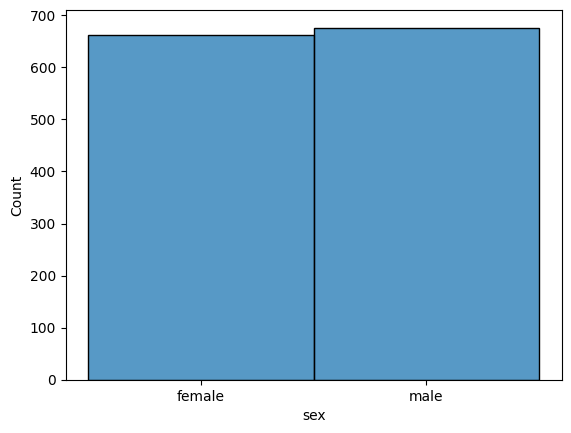

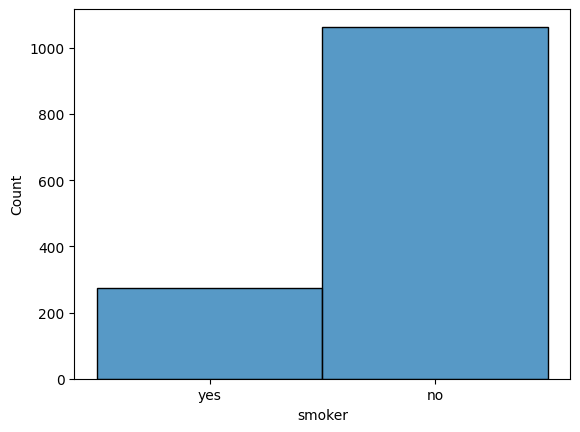

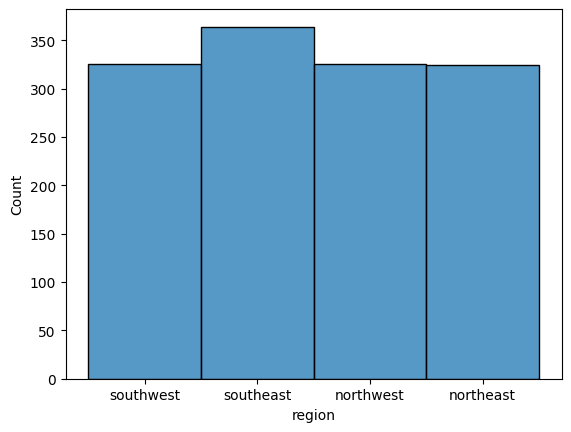

In [46]:
for i in df.select_dtypes(include=['object']).columns:
    sns.histplot(data=df, x=i)
    plt.show()

**Boxplot**

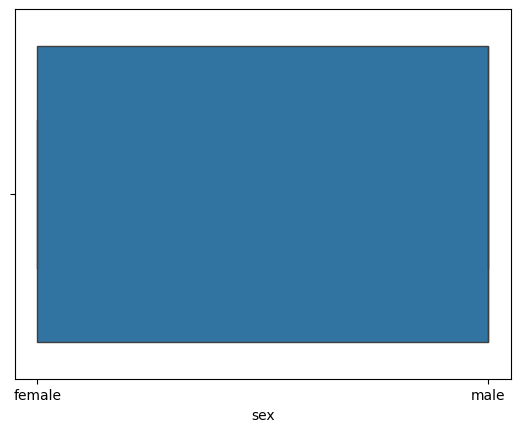

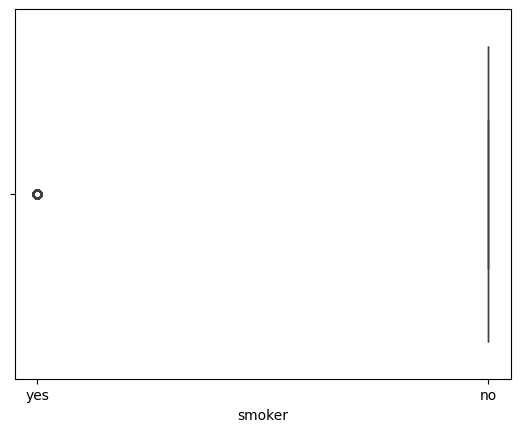

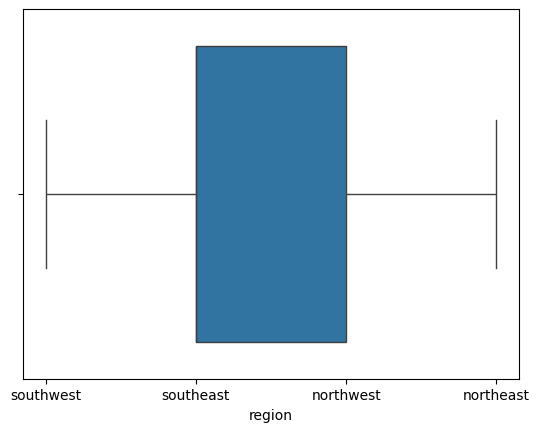

In [47]:
for i in df.select_dtypes(include=['object']).columns:
    sns.boxplot(data=df, x=i)
    plt.show()

**Scatter plot to understand the relationShip**

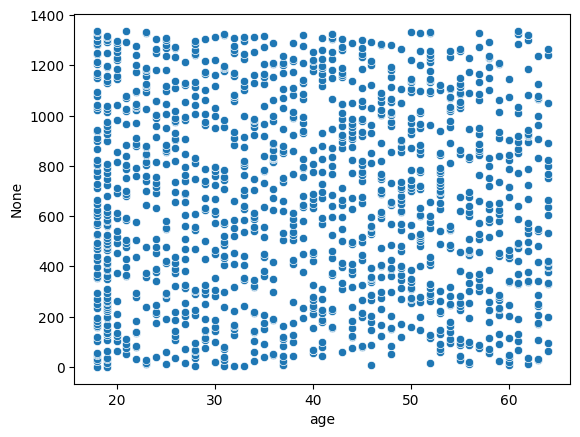

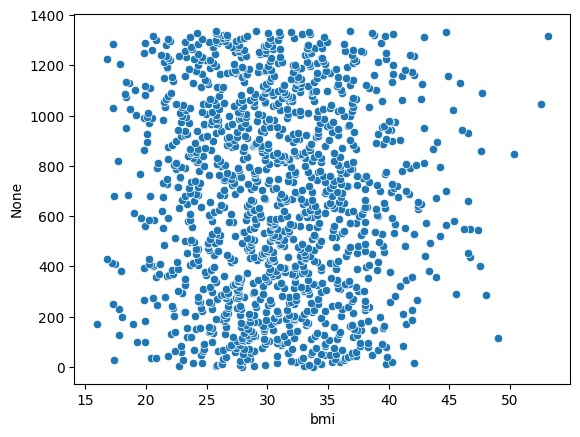

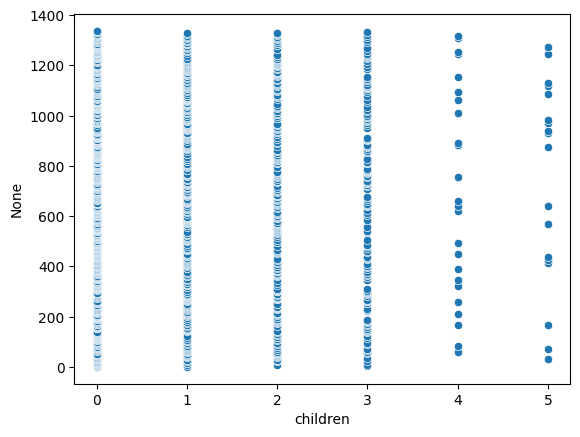

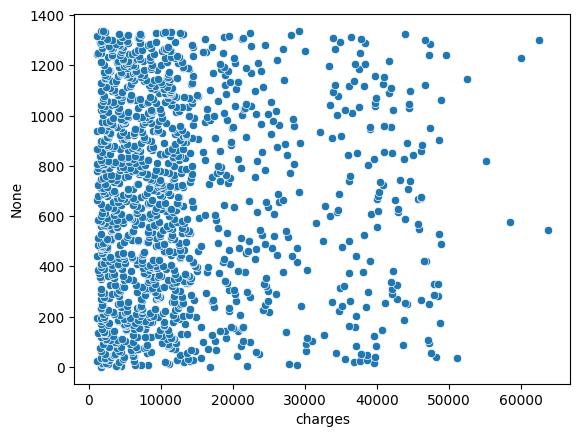

In [48]:
for i in df.select_dtypes(include="number").columns:
    sns.scatterplot(data=df, x=i, y=df.index)
    plt.show()

**Correlation with heatmap to interpret the relation and multicoliniarity**

<Axes: >

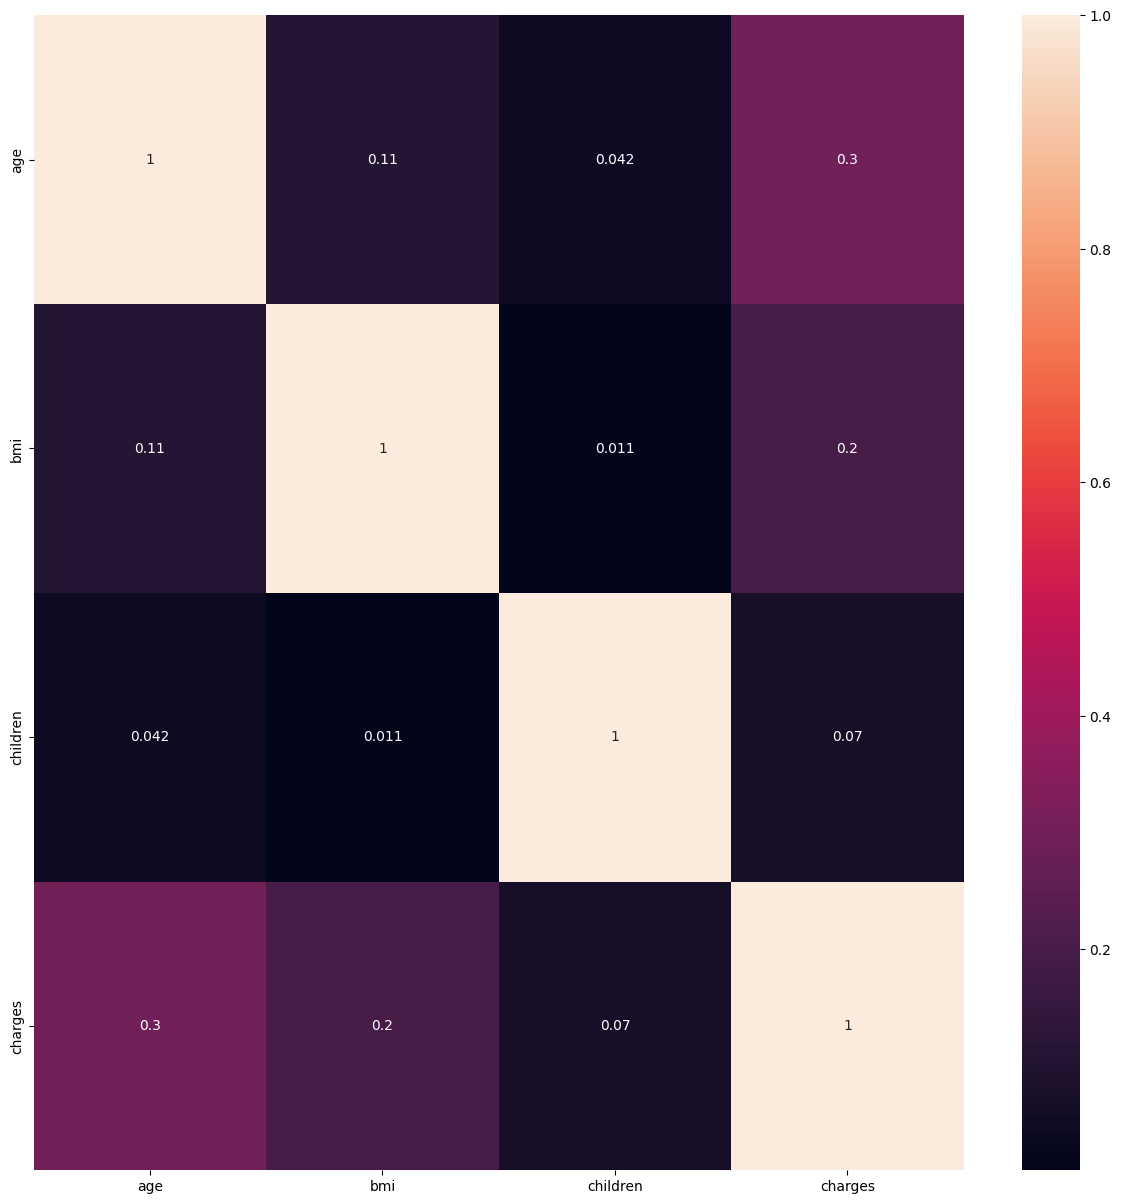

In [49]:
s= df.select_dtypes(include="number").corr()
plt.figure(figsize=(15,15))
sns.heatmap(s, annot=True)

# Missing  Value

In [50]:
from sklearn.pipeline import Pipeline
X = df.drop('charges', axis=1)
y = df['charges']

# ----------------------------
# 2) الأعمدة الرقمية و الفئوية
# ----------------------------
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# ----------------------------
# 3) Pipeline للـ preprocessing
# ----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first'))
        ]), categorical_features)
    ]
)

# ----------------------------
# 4) Preprocessing
# ----------------------------
X_processed = preprocessor.fit_transform(X)


In [51]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,13
smoker,0
region,0
charges,0


**Explore data**

## **Linear regression**

In [52]:
x_train , x_test , y_train , y_test = train_test_split(X_processed, y, test_size=0.2, random_state=1)
#7) بناء الموديل
model = LinearRegression()
model.fit(x_train, y_train)


# 9) التنبؤ على ال test set
y_pred = model.predict(x_test)
print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10])

Predictions: [ 4341.71324381 12840.91800418 12549.49733655 13357.6842262
   539.44491828 32184.13547905 12955.59195082 12277.80705802
  3744.53313803 29436.83645163]
Actual: 559      1646.42970
1087    11353.22760
1020     8798.59300
460     10381.47870
802      2103.08000
298     38746.35510
481      9304.70190
616     11658.11505
763      3070.80870
750     19539.24300
Name: charges, dtype: float64


In [53]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R2 score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 score: 0.7625689211930067
MAE: 4048.5322878603693
RMSE: 5953.474893508605


#  **Random Forest Regression**

In [56]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=1)
model_rf.fit(x_train, y_train)

# 9) التنبؤ على ال test set
y_pred_rf = model_rf.predict(x_test)
print("\n--- Random Forest Predictions vs Actual (First 10) ---")
print("Predictions:", np.around(y_pred_rf[:10], 2))
print("Actual:", y_test[:10])



--- Random Forest Predictions vs Actual (First 10) ---
Predictions: [ 1617.89 12571.89  8904.54 11362.3   2109.92 40244.85 11126.61 11599.11
  3203.3  19864.64]
Actual: 559      1646.42970
1087    11353.22760
1020     8798.59300
460     10381.47870
802      2103.08000
298     38746.35510
481      9304.70190
616     11658.11505
763      3070.80870
750     19539.24300
Name: charges, dtype: float64


In [58]:
# 8) evaluation
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("\n--- Random Forest Model Evaluation ---")
print(f"R2 score: {r2_rf:.4f}")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")


--- Random Forest Model Evaluation ---
R2 score: 0.8497
MAE: 2662.70
RMSE: 4736.68
